# High resolution total alkalinity estimation using GLODAP2

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn import metrics

import highres_ta.estimators as models
from model_selection import load_data, get_splits_by_expocode_salinity_bin_based, preprocess_data, load_config

In [3]:
from scipy.special import huber
def compute_n_coords(lat, lon):
    """
    Spherical coordinates 
    """
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return x, y, z


def scoring(y_true, y_pred) -> pd.DataFrame:
    from loguru import logger
    residuals = y_pred - y_true
    scores = pd.Series(
        {
            "root_mean_squared_error": metrics.root_mean_squared_error(y_true, y_pred),
            "mean_absolute_error": metrics.mean_absolute_error(y_true, y_pred),
            "huber_loss": huber(1.35, residuals).mean(),
            "median_absolute_error": metrics.median_absolute_error(y_true, y_pred),
            "mean_bias": residuals.mean(),
            "median_bias": residuals.median(),
            "r2_score": metrics.r2_score(y_true, y_pred),
        },
    name='Scores').to_frame()
    scores.index.name = "Metric"

    logger.info(f"\n{scores.to_markdown(floatfmt='.3f')}")

    return scores

# Load train, test data

In [4]:
config = load_config("./cv_example_config.yaml")
print(config.yname_target)
print(config.xname_features)

talk
['salinity', 'temperature', 'bottomdepth', 'depth', 'ssh_adt', 'chl_globcolour', 'ncoord_a', 'ncoord_b', 'ncoord_c']


In [5]:
df_raw = load_data()

n_coords = compute_n_coords(df_raw["lat"], df_raw["lon"])
df_raw["ncoord_a"] = n_coords[0]
df_raw["ncoord_b"] = n_coords[1]
df_raw["ncoord_c"] = n_coords[2]

df = preprocess_data(df_raw, config)

# filter out very low salinity, and shallow seas
filter = (df["salinity"] > 25) & (df["salinity"] < 40) & (df["bottomdepth"] > 150)
df = df[filter]

itrain, itest = get_splits_by_expocode_salinity_bin_based(df)[2]
train_x = df.iloc[itrain][config.xname_features]
train_y = df.iloc[itrain][config.yname_target]
test_x = df.iloc[itest][config.xname_features]
test_y = df.iloc[itest][config.yname_target]

2026-04-22 13:18:42.556 | INFO     | model_selection:load_data:167 - Loading data from /Users/luke/Work/OceanCO2/highres_TA/data/training/GLODAPv2023-raw_collocated-YYYY.pq for years 1982-2021


In [22]:
linear_features = ["salinity"]  # better than when including temperature

bagged_model = models.BaggingCatBoostResidualRegressor(
    n_estimators=5, 
    iterations=1000,
    polynomial_degree=2,
    max_samples=0.33,
    loss_function="MAE",
    linear_features=linear_features,
    min_data_in_leaf=40,
    n_jobs=8,
)


In [23]:
bagged_model.fit(train_x, train_y)
pred_y = bagged_model.predict(test_x)
scores = scoring(test_y, pred_y)

ValueError: Missing linear feature columns: salinity

In [7]:
bagged_model.fit(train_x, train_y)
train_yhat = bagged_model.predict(train_x)
_ = scoring(train_y, train_yhat)

ValueError: Missing linear feature columns: salinity

In [59]:
# the prediction flow:
# 1) get the baseline prediction from the linear model
# 2) get the residual prediction from the bagged booster
# 3) sum them to get the final prediction
test_yhat = bagged_model.predict(test_x)
test_yhat_linear = bagged_model.predict_linear(test_x)

# _ = scoring(test_y, test_yhat_linear)
_ = scoring(test_y, test_yhat)

2026-04-22 13:11:39.221 | INFO     | __main__:scoring:30 - 
| Metric                  |   Scores |
|:------------------------|---------:|
| root_mean_squared_error |   15.465 |
| mean_absolute_error     |    7.135 |
| huber_loss              |    8.792 |
| median_absolute_error   |    3.370 |
| mean_bias               |    0.118 |
| median_bias             |    0.566 |
| r2_score                |    0.974 |


# Load inference data (single timestep)

In [60]:
url = "https://data.up.ethz.ch/shared/OceanSODA-ETHZv2/.inference_for_gregor2024/data_8daily_25km_v01.zarr/"
ds = xr.open_zarr(url, consolidated=True, group='2004')

ds["bottomdepth"] = xr.open_dataarray("../data/bathymetry_etopo2022_25km.nc")
rename = dict(
    sss="salinity",
    sst="temperature",
    ssh="ssh_adt",
    ssh_anom="ssh_sla",
    mld="mld_dens_soda",
    chl_filled="chl_globcolour",
    bottomdepth="bottomdepth",
)
ds = ds.rename(rename)[list(rename.values())]
ds = ds.isel(time=33, drop=True)
df = ds.to_dataframe()
coords = df.index.to_frame()
df['ncoord_a'], df['ncoord_b'], df['ncoord_c'] = compute_n_coords(coords['lat'], coords['lon'])
df['depth'] = 0

coords = df.index.to_frame()
n_coords = compute_n_coords(coords["lat"], coords["lon"])
df = df.join(n_coords)
pred_X = df.dropna()[train_x.columns]

# Create mapped estimates

In [61]:
import numpy as np
full_results = np.vstack((bagged_model.predict(pred_X, return_std=True),
bagged_model.predict_linear(pred_X, return_std=True),
bagged_model.predict_catboost(pred_X, return_std=True),
)
)

In [28]:
url = "https://datadocs.bco-dmo.org/dataset/3782/file/wn3zAMZuP0Arwj/3782_v9_bats_bottle.csv"
url = "https://datadocs.bco-dmo.org/dataset/3773/file/QArEXBMh6mlRyk/3773_v3_niskin_hot001_yr01_to_hot348_yr35.csv"

In [29]:
import pooch


fname = pooch.retrieve(
    url=url,
    known_hash=None,
    fname=url.split("/")[-1],
)

pd.read_csv(fname)

SHA256 hash of downloaded file: 1903b8917de5668cba05121629ff3914a15375e0e293bb87b9ffd744095086eb
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


,HOT_ID,Vessel,EXPOCODE,WHPID_section,Sampling_ISO_DateTime_UTC,Latitude,Longitude,Depth_max,Pressure_max,STNNBR,...,QUALT2,QUALT3,QUALT4,QUALT5,QUALT6,QUALT7,QUALT8,QUALT9,QUALT10,Cruise_number
0,HOT-348,R/V Kilo Moana,33KB348/1,PRS2,2023-12-30T20:36Z,22.7813,-157.9222,4697.0,202.0,50,...,9999999,9999999,9999999,9999999,999999,999999,999999,999999,999999,348
1,HOT-348,R/V Kilo Moana,33KB348/1,PRS2,2023-12-31T06:39Z,21.8457,-158.3610,2437.0,2454.0,6,...,9999999,9999999,9559999,9999999,999999,999999,999999,999999,999999,348
2,HOT-348,R/V Kilo Moana,33KB348/1,PRS2,2023-12-31T06:39Z,21.8457,-158.3610,2437.0,2454.0,6,...,9999999,9999999,9559999,9999999,999999,999999,999999,999999,999999,348
3,HOT-348,R/V Kilo Moana,33KB348/1,PRS2,2023-12-31T06:39Z,21.8457,-158.3610,2437.0,2454.0,6,...,9999999,9999999,9559999,9999999,999999,999999,999999,999999,999999,348
4,HOT-348,R/V Kilo Moana,33KB348/1,PRS2,2023-12-31T06:39Z,21.8457,-158.3610,2437.0,2454.0,6,...,9999999,9999999,9559999,9999999,999999,999999,999999,999999,999999,348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108554,HOT-001,R/V Moana Wave,32MW001/1,PRS2,1988-10-31T00:56Z,22.7600,-157.9983,4750.0,1016.0,2,...,9222999,9999999,9999999,9999999,999999,999999,999999,999999,999999,1
108555,HOT-001,R/V Moana Wave,32MW001/1,PRS2,1988-10-31T00:56Z,22.7600,-157.9983,4750.0,1016.0,2,...,9222999,9999999,9999999,9999999,999999,999999,999999,999999,999999,1
108556,HOT-001,R/V Moana Wave,32MW001/1,PRS2,1988-10-31T00:56Z,22.7600,-157.9983,4750.0,1016.0,2,...,9222999,9999999,9999999,9999999,999999,999999,999999,999999,999999,1
108557,HOT-001,R/V Moana Wave,32MW001/1,PRS2,1988-10-31T00:56Z,22.7600,-157.9983,4750.0,1016.0,2,...,9222999,9999999,9999999,9999999,999999,999999,999999,999999,999999,1


In [54]:
pred_y = pd.DataFrame(
    data=full_results.T,
    columns=["mean_prediction", "std_prediction", "mean_linear", "std_linear", "mean_catboost", "std_catboost"],
    index=pred_X.index,
).to_xarray().astype("float32").chunk()
pred_y["std_combined"] = ((pred_y.std_catboost**2 + pred_y.std_linear**2)**0.5).chunk()

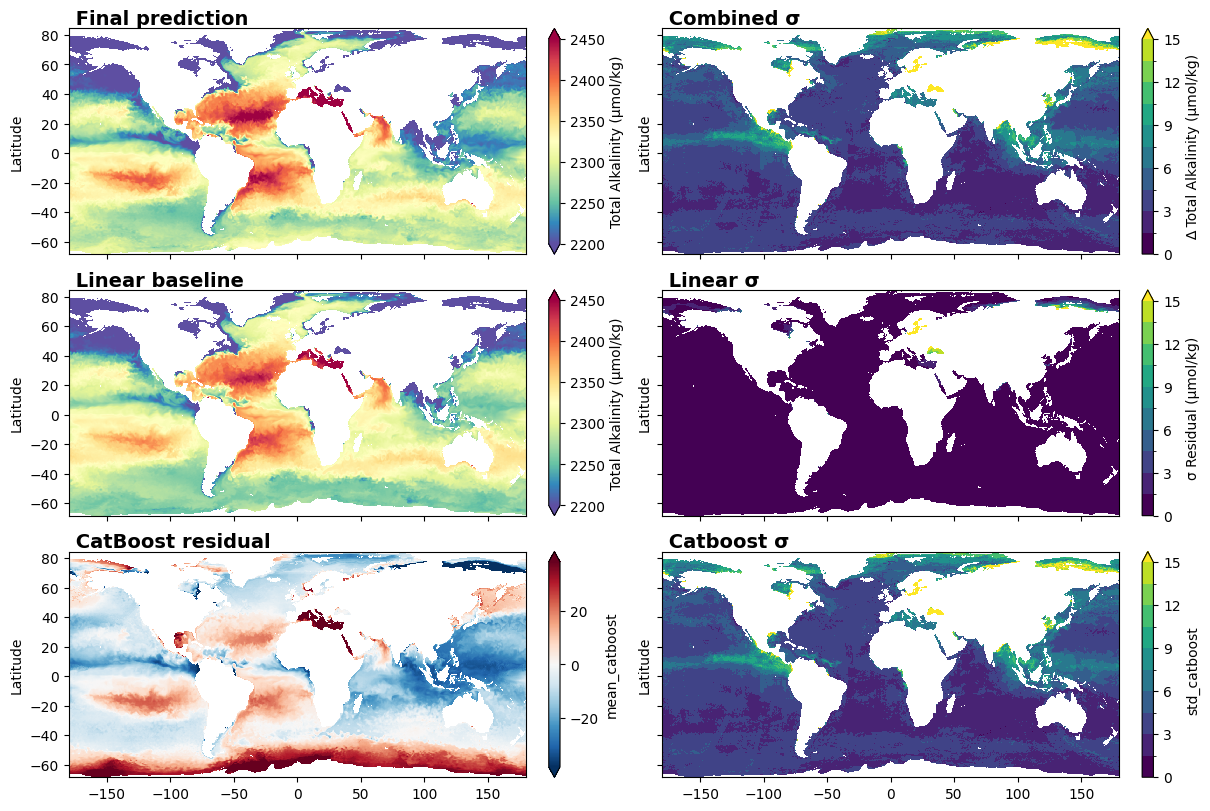

In [55]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(12, 8), squeeze=False, sharex=True, sharey=True, constrained_layout=True)
img1 = pred_y.mean_prediction.plot.imshow(vmin=2200, vmax=2450, ax=axs[0, 0], cmap="Spectral_r")
img2 = pred_y.std_combined.plot.imshow(vmin=0, vmax=15, ax=axs[0, 1], levels=11)
img3 = pred_y.mean_linear.plot.imshow(vmin=2200, vmax=2450, ax=axs[1, 0], cmap="Spectral_r")
img4 = pred_y.std_linear.plot.imshow(vmin=0, vmax=15, ax=axs[1, 1], levels=11)
img5 = pred_y.mean_catboost.plot.imshow(robust=True, ax=axs[2, 0])
img6 = pred_y.std_catboost.plot.imshow(vmin=0, vmax=15, ax=axs[2, 1], levels=11)

[ax.set_ylabel('') for ax in axs.flat]
[ax.set_xlabel('') for ax in axs.flat]

# img3.get_clim()
# img1.set_clim(img3.get_clim())

img1.colorbar.set_label("Total Alkalinity (µmol/kg)")
img2.colorbar.set_label("∆ Total Alkalinity (µmol/kg)")
img3.colorbar.set_label("Total Alkalinity (µmol/kg)")
img4.colorbar.set_label("σ Residual (µmol/kg)")

text_props = dict(fontsize=14, fontweight='bold', color='black', loc='left', va='top')
axs = axs.flatten()
axs[0].set_title(" Final prediction", **text_props)
axs[1].set_title(" Combined σ", **text_props)
axs[2].set_title(" Linear baseline", **text_props)
axs[3].set_title(" Linear σ", **text_props)
axs[4].set_title(" CatBoost residual", **text_props)
axs[5].set_title(" Catboost σ", **text_props)

for ax in axs.flatten():
    ax.set_xlabel("")
    ax.set_ylabel("Latitude")

<Axes: >

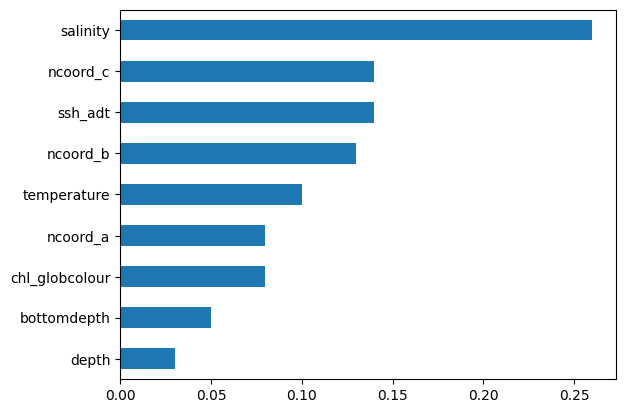

In [44]:
pd.Series(bagged_model.estimators_[0].boosting_model_.get_feature_importance(), index=train_x.columns).pipe(lambda s: s / s.sum()).sort_values(ascending=True).round(2).plot.barh()